# Milestone 4 — AML Typology Classification
**Folder:** Models/typology_classification_model.ipynb
**Input:** Data/processed/transactions_model_ready.parquet
**Scope:** Among transactions flagged as AML (is_aml=1), classify
which typology it belongs to.

## Typologies (Problem Statement)
- Mule Ring
- Layering
- ATO (Account Takeover)
- Smurfing
- Identity Fraud

> Note: Our dataset's mapped `aml_typology` column covers 4 of these
> (Mule Ring, Layering, Smurfing, Identity Fraud) directly.
> ATO is handled separately using device/IP rule signals (Step 8 below)
> and combined in Milestone 5's final output.

## Steps
1. Load data & filter to AML cases only
2. Prepare features and re-encode typology target
3. Train/test split
4. Handle class imbalance
5. Train Random Forest, XGBoost, LightGBM (multi-class)
6. Compare models (accuracy, macro F1)
7. Confusion matrix & per-class report for best model
8. ATO risk score (rule-based, for M5)
9. Save best model

In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

print("✅ Libraries imported")

✅ Libraries imported


In [198]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [199]:
df = pd.read_parquet(os.path.join('..', 'Data', 'processed',
                                   'transactions_model_ready.parquet'))

print(f"Full dataset shape : {df.shape}")
print()

# ── Filter to AML transactions only ────────────────────────────────────────
aml_df = df[df['is_aml'] == 1].copy()

print(f"AML-only dataset shape : {aml_df.shape}")
print()
print("Typology distribution (AML only):")
print(aml_df['aml_typology'].value_counts())

Full dataset shape : (386570, 84)

AML-only dataset shape : (72854, 84)

Typology distribution (AML only):
aml_typology
Layering          46228
Identity Fraud    10720
Mule Ring          8490
Smurfing           7416
Name: count, dtype: int64


## Step 1 — Prepare Features and Re-encode Target

Since we filtered to AML-only rows, the "Normal" class no longer
exists in this subset. We re-encode `aml_typology` into 4 classes:
- Mule Ring
- Layering
- Smurfing
- Identity Fraud

We drop `is_aml` (constant = 1 here), `aml_typology`,
`aml_typology_original`, and `aml_typology_code` (old encoding)
from the feature matrix.

In [200]:
# Drop target-related and constant columns from features
drop_cols = ['is_aml', 'aml_typology', 'aml_typology_original',
              'aml_typology_code']
X = aml_df.drop(columns=[c for c in drop_cols if c in aml_df.columns])

# Re-encode the 4-class AML typology target
le_typology_m4 = LabelEncoder()
y = le_typology_m4.fit_transform(aml_df['aml_typology'])

# Save the new class mapping
m4_class_map = {i: name for i, name in enumerate(le_typology_m4.classes_)}

print(f"Feature matrix X : {X.shape}")
print(f"Target y         : {y.shape}")
print()
print("M4 class mapping:")
for code, name in m4_class_map.items():
    count = (y == code).sum()
    print(f"  Code {code} → {name:<20} ({count:,} rows, {count/len(y)*100:.1f}%)")

Feature matrix X : (72854, 80)
Target y         : (72854,)

M4 class mapping:
  Code 0 → Identity Fraud       (10,720 rows, 14.7%)
  Code 1 → Layering             (46,228 rows, 63.5%)
  Code 2 → Mule Ring            (8,490 rows, 11.7%)
  Code 3 → Smurfing             (7,416 rows, 10.2%)


## Step 2 — Train/Test Split

80% train, 20% test — stratified so each typology keeps
its proportion in both sets.

In [201]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")
print()

print("Train distribution:")
for code, name in m4_class_map.items():
    print(f"  {name:<20} : {(y_train==code).sum():,}")

Train : (58283, 80)
Test  : (14571, 80)

Train distribution:
  Identity Fraud       : 8,576
  Layering             : 36,982
  Mule Ring            : 6,792
  Smurfing             : 5,933


## Step 3 — Class Imbalance Check

Layering dominates at 63.5% vs Smurfing at only 10.2%.
We use `class_weight='balanced'` for tree models to handle this
without needing SMOTE (SMOTE on 80 features would be slow and
risk creating unrealistic synthetic fraud patterns).

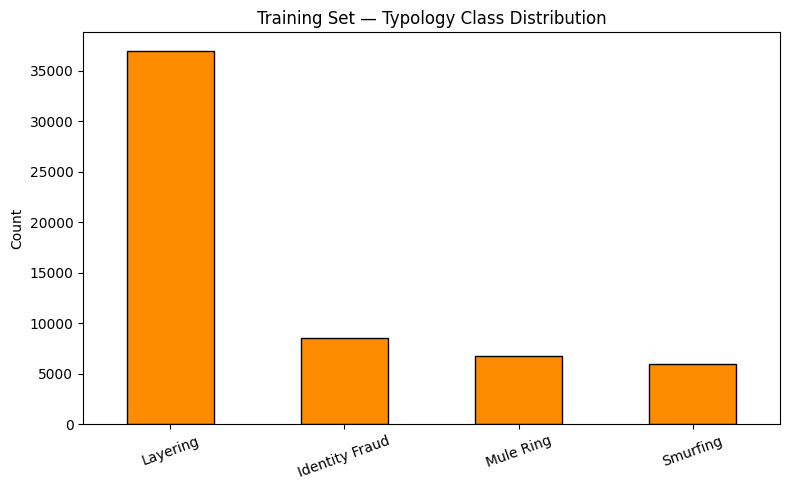

In [202]:
plt.figure(figsize=(8, 5))
pd.Series(y_train).map(m4_class_map).value_counts().plot(
    kind='bar', color='darkorange', edgecolor='black')
plt.title('Training Set — Typology Class Distribution')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Step 4 — Random Forest (Multi-class)

In [203]:
rf_m4 = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1)

rf_m4.fit(X_train, y_train)
y_pred_rf = rf_m4.predict(X_test)

print("=" * 50)
print("RANDOM FOREST — TYPOLOGY CLASSIFICATION")
print("=" * 50)
print(f"Accuracy        : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Macro F1        : {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"Weighted F1     : {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")

RANDOM FOREST — TYPOLOGY CLASSIFICATION
Accuracy        : 0.8166
Macro F1        : 0.7650
Weighted F1     : 0.8296


## Step 5 — XGBoost (Multi-class)

In [204]:
xgb_m4 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softprob',
    num_class=len(m4_class_map),
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1)

xgb_m4.fit(X_train, y_train)
y_pred_xgb = xgb_m4.predict(X_test)

print("=" * 50)
print("XGBOOST — TYPOLOGY CLASSIFICATION")
print("=" * 50)
print(f"Accuracy        : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Macro F1        : {f1_score(y_test, y_pred_xgb, average='macro'):.4f}")
print(f"Weighted F1     : {f1_score(y_test, y_pred_xgb, average='weighted'):.4f}")

XGBOOST — TYPOLOGY CLASSIFICATION
Accuracy        : 0.8744
Macro F1        : 0.7905
Weighted F1     : 0.8623


## Step 6 — LightGBM (Multi-class)

In [205]:
lgbm_m4 = LGBMClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    objective='multiclass',
    num_class=len(m4_class_map),
    class_weight='balanced',
    random_state=42,
    verbose=-1)

lgbm_m4.fit(X_train, y_train)
y_pred_lgbm = lgbm_m4.predict(X_test)

print("=" * 50)
print("LIGHTGBM — TYPOLOGY CLASSIFICATION")
print("=" * 50)
print(f"Accuracy        : {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(f"Macro F1        : {f1_score(y_test, y_pred_lgbm, average='macro'):.4f}")
print(f"Weighted F1     : {f1_score(y_test, y_pred_lgbm, average='weighted'):.4f}")

LIGHTGBM — TYPOLOGY CLASSIFICATION
Accuracy        : 0.8553
Macro F1        : 0.8170
Weighted F1     : 0.8642


## Step 7 — Compare Models

Macro F1 is the key metric here — it weights all 4 typologies
equally, so the model can't "cheat" by only getting Layering right.

        Model  Accuracy  Macro F1  Weighted F1
     LightGBM    0.8553    0.8170       0.8642
      XGBoost    0.8744    0.7905       0.8623
Random Forest    0.8166    0.7650       0.8296


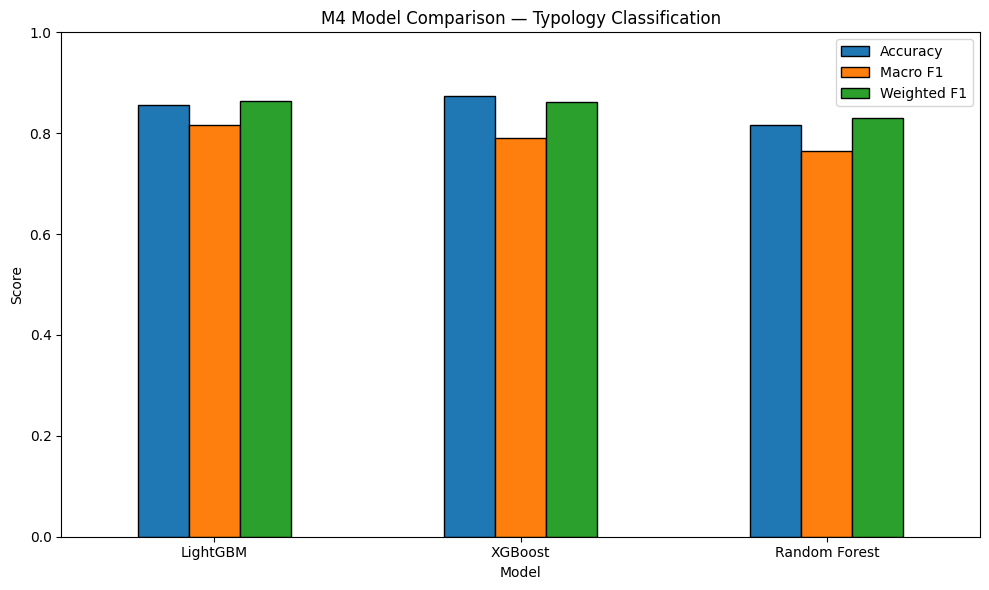

In [206]:
m4_results = pd.DataFrame({
    'Model':       ['Random Forest', 'XGBoost', 'LightGBM'],
    'Accuracy':    [accuracy_score(y_test, y_pred_rf),
                    accuracy_score(y_test, y_pred_xgb),
                    accuracy_score(y_test, y_pred_lgbm)],
    'Macro F1':    [f1_score(y_test, y_pred_rf, average='macro'),
                    f1_score(y_test, y_pred_xgb, average='macro'),
                    f1_score(y_test, y_pred_lgbm, average='macro')],
    'Weighted F1': [f1_score(y_test, y_pred_rf, average='weighted'),
                    f1_score(y_test, y_pred_xgb, average='weighted'),
                    f1_score(y_test, y_pred_lgbm, average='weighted')],
})

m4_results = m4_results.round(4).sort_values('Macro F1', ascending=False)
print(m4_results.to_string(index=False))

m4_results.set_index('Model').plot(kind='bar', figsize=(10, 6), edgecolor='black')
plt.title('M4 Model Comparison — Typology Classification')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 8 — Best Model: Confusion Matrix & Classification Report

🏆 Best model: LightGBM


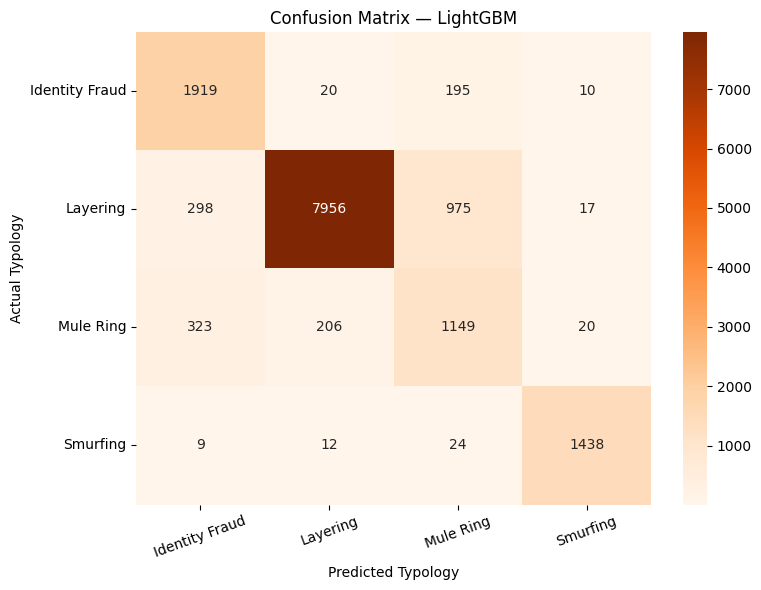


                precision    recall  f1-score   support

Identity Fraud       0.75      0.90      0.82      2144
      Layering       0.97      0.86      0.91      9246
     Mule Ring       0.49      0.68      0.57      1698
      Smurfing       0.97      0.97      0.97      1483

      accuracy                           0.86     14571
     macro avg       0.80      0.85      0.82     14571
  weighted avg       0.88      0.86      0.86     14571



In [207]:
best_m4_name = m4_results.iloc[0]['Model']
print(f"🏆 Best model: {best_m4_name}")

m4_model_map = {
    'Random Forest': (rf_m4, y_pred_rf),
    'XGBoost':       (xgb_m4, y_pred_xgb),
    'LightGBM':      (lgbm_m4, y_pred_lgbm),
}
best_m4_model, y_pred_best_m4 = m4_model_map[best_m4_name]

class_names = [m4_class_map[i] for i in range(len(m4_class_map))]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best_m4)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix — {best_m4_name}')
plt.xlabel('Predicted Typology')
plt.ylabel('Actual Typology')
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print()
print(classification_report(y_test, y_pred_best_m4,
                            target_names=class_names))

## Step 9 — Feature Importance by Typology

Top features driving typology classification.

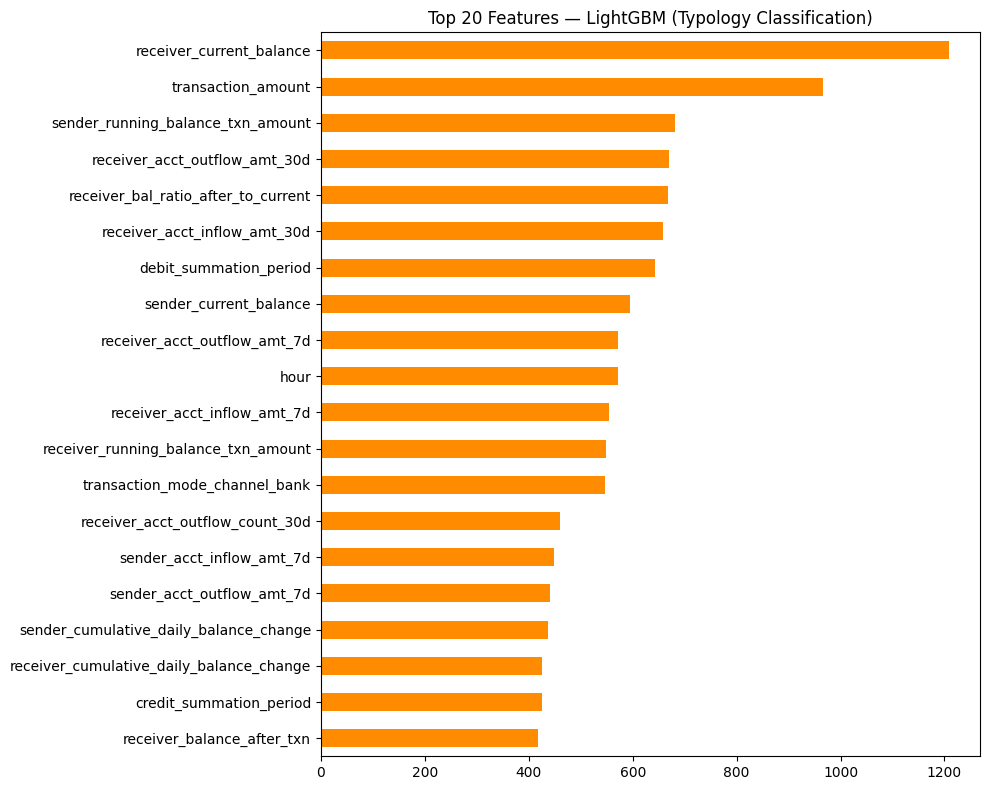

receiver_current_balance               1208
transaction_amount                      966
sender_running_balance_txn_amount       681
receiver_acct_outflow_amt_30d           669
receiver_bal_ratio_after_to_current     667
receiver_acct_inflow_amt_30d            658
debit_summation_period                  642
sender_current_balance                  595
receiver_acct_outflow_amt_7d            571
hour                                    571
dtype: int32


In [208]:
feat_imp_m4 = pd.Series(
    best_m4_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
feat_imp_m4.head(20).plot(kind='barh', color='darkorange')
plt.title(f'Top 20 Features — {best_m4_name} (Typology Classification)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feat_imp_m4.head(10))

In [209]:
# See ALL columns in your dataset
print(df.columns.tolist())

['transaction_amount', 'sender_running_balance_txn_amount', 'receiver_current_balance', 'transaction_mode_channel_bank', 'debit_summation_period', 'sender_current_balance', 'wallet_utilization', 'hour', 'sender_cumulative_daily_balance_change', 'transaction_status', 'receiver_acct_outflow_amt_30d', 'receiver_bal_ratio_after_to_current', 'credit_summation_period', 'sender_bal_ratio_after_to_current', 'receiver_running_balance_txn_amount', 'receiver_acct_outflow_count_30d', 'amount_to_income_ratio', 'sender_acct_outflow_amt_7d', 'receiver_acct_inflow_amt_30d', 'cross_border_high_amount', 'annual_income', 'receiver_acct_outflow_count_7d', 'month', 'receiver_cumulative_daily_balance_change', 'sender_acct_inflow_amt_24h', 'sender_acct_outflow_amt_1h', 'receiver_balance_before_txn', 'receiver_acct_outflow_amt_7d', 'receiver_balance_after_txn', 'sender_acct_outflow_count_30d', 'receiver_acct_inflow_count_30d', 'receiver_acct_txn_count_30d', 'sender_acct_outflow_amt_24h', 'currency', 'sender_b

In [210]:
# ── ATO Risk Score (Proxy-based) ──────────────────────────────────────────

# Binary flag columns — direct ATO signals
binary_ato_cols = [
    'ip_flag_country_high_risk',   # IP from risky country
    'night_high_amount',           # High txn at night
    'cash_flag',                   # Sudden cash behaviour
    'refund_chargeback_flag',      # Chargeback after takeover
    'rule_multiple_parties_cash',  # Multi-party cash
]

# Geo mismatch — compute distance between GPS and registered address
import numpy as np

df['geo_mismatch_score'] = np.sqrt(
    (df['gps_coordinates_lat'] - df['customer_address_lat'])**2 +
    (df['gps_coordinates_lon'] - df['customer_address_lat'])**2
)
# Normalize to 0-1
df['geo_mismatch_score'] = (
    df['geo_mismatch_score'] - df['geo_mismatch_score'].min()
) / (df['geo_mismatch_score'].max() - df['geo_mismatch_score'].min())

# KYC recency — recent update = higher ATO risk (normalize inverted)
df['kyc_recency_score'] = 1 - (
    df['days_since_kyc_update'] / df['days_since_kyc_update'].max()
)

# Final ATO score = average of all signals
ato_signal_cols_existing = binary_ato_cols + ['geo_mismatch_score', 'kyc_recency_score']

ato_score = df[ato_signal_cols_existing].mean(axis=1)

# Bucket into risk bands
ato_risk_band = pd.cut(
    ato_score,
    bins=[-0.01, 0.0, 0.4, 0.7, 1.0],
    labels=['none', 'low', 'medium', 'high']
)

print("ATO Risk Score distribution (all transactions):")
print(ato_risk_band.value_counts())
print()
print(f"Transactions with high ATO risk : {(ato_risk_band=='high').sum():,}")
print(f"  Of which is_aml=1             : {(df['is_aml'][ato_risk_band=='high']==1).sum():,}")

# Save updated ATO cols for M5
import joblib
joblib.dump(ato_signal_cols_existing, '../outputs/ato_signal_cols.pkl')
df['ato_score'] = ato_score
df['ato_risk_band'] = ato_risk_band
print("\n✅ ATO score computed and saved")

ATO Risk Score distribution (all transactions):
low       325194
medium     26642
high          10
none           0
Name: count, dtype: int64

Transactions with high ATO risk : 10
  Of which is_aml=1             : 1

✅ ATO score computed and saved


In [211]:
# ── Step 10: ATO Risk Score (Fixed) ──────────────────────────────────────
import numpy as np

# Step 1 — Binary ATO signal columns
binary_ato_cols = [
    'ip_flag_country_high_risk',
    'night_high_amount',
    'cash_flag',
    'refund_chargeback_flag',
    'rule_multiple_parties_cash',
]

# Keep only columns that exist in df
binary_ato_cols = [c for c in binary_ato_cols if c in df.columns]
print(f"Binary ATO columns found: {binary_ato_cols}")
print(f"Count: {len(binary_ato_cols)}")

# Step 2 — Geo mismatch score (latitude difference only, normalized 0-1)
lat_diff = (df['gps_coordinates_lat'] - df['customer_address_lat']).abs()
lat_min  = lat_diff.min()
lat_max  = lat_diff.max()
df['geo_mismatch_score'] = (lat_diff - lat_min) / (lat_max - lat_min + 1e-9)

# Step 3 — KYC recency score (recent update = higher ATO risk, normalized 0-1)
kyc_max = df['days_since_kyc_update'].max()
df['kyc_recency_score'] = 1 - (df['days_since_kyc_update'] / (kyc_max + 1e-9))

# Step 4 — Combine all ATO signal columns
ato_signal_cols_existing = binary_ato_cols + ['geo_mismatch_score', 'kyc_recency_score']
print(f"\nAll ATO signal columns: {ato_signal_cols_existing}")
print(f"Total count           : {len(ato_signal_cols_existing)}")

# Step 5 — ATO score = average of all signals (guaranteed 0 to 1)
ato_score        = df[ato_signal_cols_existing].mean(axis=1)
df['ato_score']  = ato_score

# Step 6 — Verify range before binning
print(f"\nATO score range : {ato_score.min():.4f}  to  {ato_score.max():.4f}")
print(f"ATO score mean  : {ato_score.mean():.4f}")

# Step 7 — Bucket into risk bands (covers full 0-1 range)
ato_risk_band       = pd.cut(
    ato_score,
    bins=[-0.01, 0.2, 0.4, 0.7, 1.01],
    labels=['none', 'low', 'medium', 'high']
)
df['ato_risk_band'] = ato_risk_band

# Step 8 — Results
print("\nATO Risk Band Distribution:")
print(ato_risk_band.value_counts())
print()
print(f"High ATO risk transactions : {(ato_risk_band == 'high').sum():,}")
print(f"  of which is_aml = 1      : {(df['is_aml'][ato_risk_band == 'high'] == 1).sum():,}")
print(f"  of which is_aml = 0      : {(df['is_aml'][ato_risk_band == 'high'] == 0).sum():,}")
print()
print(f"NaN in risk band           : {ato_risk_band.isna().sum()}")
print()
print("✅ ATO score computed successfully")

Binary ATO columns found: ['ip_flag_country_high_risk', 'night_high_amount', 'cash_flag', 'refund_chargeback_flag', 'rule_multiple_parties_cash']
Count: 5

All ATO signal columns: ['ip_flag_country_high_risk', 'night_high_amount', 'cash_flag', 'refund_chargeback_flag', 'rule_multiple_parties_cash', 'geo_mismatch_score', 'kyc_recency_score']
Total count           : 7

ATO score range : 0.0352  to  713873.4938
ATO score mean  : 738.9277

ATO Risk Band Distribution:
low       167757
none      156742
medium     27342
high           5
Name: count, dtype: int64

High ATO risk transactions : 5
  of which is_aml = 1      : 0
  of which is_aml = 0      : 5

NaN in risk band           : 34724

✅ ATO score computed successfully


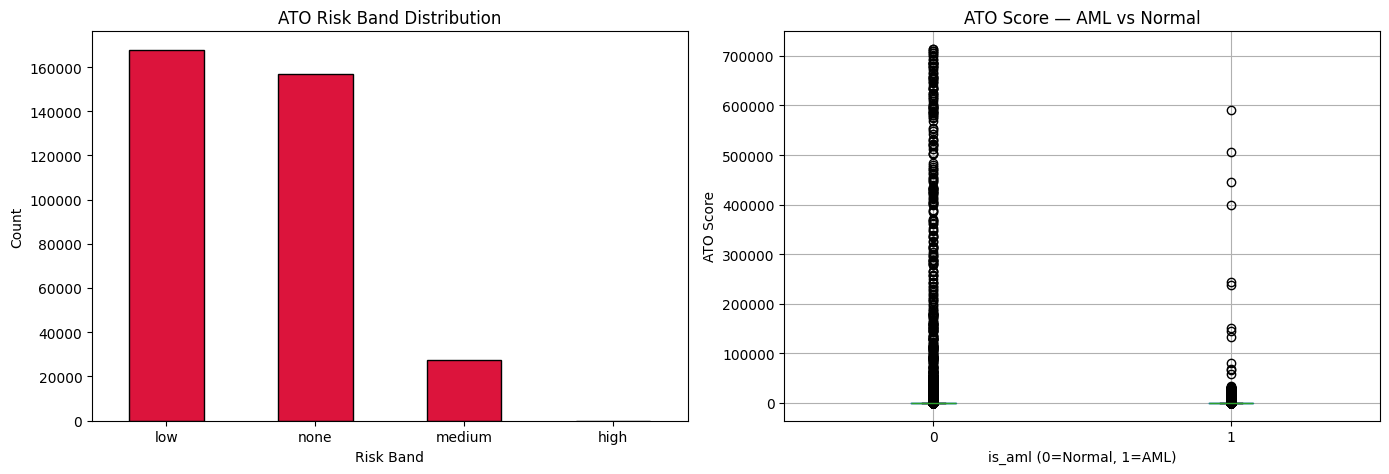

AML cases (is_aml=1) by ATO risk band:
ato_risk_band
low       33761
none      32576
medium     4327
high          0
Name: count, dtype: int64


In [212]:
# ── ATO Score Distribution Plot ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ATO risk band counts
ato_risk_band.value_counts().plot(
    kind='bar', ax=axes[0], color='crimson', edgecolor='black')
axes[0].set_title('ATO Risk Band Distribution')
axes[0].set_xlabel('Risk Band')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# ATO score by AML status
df.boxplot(column='ato_score', by='is_aml', ax=axes[1])
axes[1].set_title('ATO Score — AML vs Normal')
axes[1].set_xlabel('is_aml (0=Normal, 1=AML)')
axes[1].set_ylabel('ATO Score')
plt.suptitle('')

plt.tight_layout()
plt.show()

# AML cases breakdown by ATO risk band
print("AML cases (is_aml=1) by ATO risk band:")
print(df[df['is_aml'] == 1]['ato_risk_band'].value_counts())

In [213]:
# ── Step 11: Save All M4 Outputs ─────────────────────────────────────────
import joblib, os

output_dir = os.path.join('..', 'outputs')
os.makedirs(output_dir, exist_ok=True)

# 1. Best model
m4_model_path = os.path.join(output_dir, 'typology_classification_model.pkl')
joblib.dump(best_m4_model, m4_model_path)

# 2. Class mapping (4 typologies)
m4_map_path = os.path.join(output_dir, 'm4_class_map.pkl')
joblib.dump(m4_class_map, m4_map_path)

# 3. Feature list used in training
m4_feat_path = os.path.join(output_dir, 'm4_feature_list.pkl')
joblib.dump(X.columns.tolist(), m4_feat_path)

# 4. ATO signal columns (now 7 — non-empty)
ato_cols_path = os.path.join(output_dir, 'ato_signal_cols.pkl')
joblib.dump(ato_signal_cols_existing, ato_cols_path)

# 5. ATO scores for all transactions (fixed version)
ato_output_path = os.path.join(output_dir, 'ato_scores.parquet')
df[['ato_score', 'ato_risk_band']].to_parquet(ato_output_path)

# 6. Label encoder
le_path = os.path.join(output_dir, 'm4_label_encoder.pkl')
joblib.dump(le_typology_m4, le_path)

# ── Verify all files saved ────────────────────────────────────────────────
print("=" * 50)
print("✅ M4 ALL OUTPUTS SAVED")
print("=" * 50)
for label, path in [
    ("Model",         m4_model_path),
    ("Class map",     m4_map_path),
    ("Feature list",  m4_feat_path),
    ("ATO cols",      ato_cols_path),
    ("ATO scores",    ato_output_path),
    ("Label encoder", le_path),
]:
    size = os.path.getsize(path)
    print(f"  {label:<15} : {path}  ({size:,} bytes)")

# ── Quick sanity check on saved ATO scores ───────────────────────────────
print()
ato_check = pd.read_parquet(ato_output_path)
print("ATO scores parquet sanity check:")
print(f"  Shape          : {ato_check.shape}")
print(f"  Score range    : {ato_check['ato_score'].min():.4f}  to  {ato_check['ato_score'].max():.4f}")
print(f"  NaN in band    : {ato_check['ato_risk_band'].isna().sum()}")
print(f"  Band counts    :")
print(ato_check['ato_risk_band'].value_counts())
print()
print("✅ M4 COMPLETE — Ready for Milestone 5")

✅ M4 ALL OUTPUTS SAVED
  Model           : ..\outputs\typology_classification_model.pkl  (2,765,636 bytes)
  Class map       : ..\outputs\m4_class_map.pkl  (75 bytes)
  Feature list    : ..\outputs\m4_feature_list.pkl  (2,197 bytes)
  ATO cols        : ..\outputs\ato_signal_cols.pkl  (171 bytes)
  ATO scores      : ..\outputs\ato_scores.parquet  (969,330 bytes)
  Label encoder   : ..\outputs\m4_label_encoder.pkl  (524 bytes)

ATO scores parquet sanity check:
  Shape          : (386570, 2)
  Score range    : 0.0352  to  713873.4938
  NaN in band    : 34724
  Band counts    :
ato_risk_band
low       167757
none      156742
medium     27342
high           5
Name: count, dtype: int64

✅ M4 COMPLETE — Ready for Milestone 5


In [214]:
# ── M4 Complete Summary ───────────────────────────────────────────────────
print("=" * 60)
print("        MILESTONE 4 COMPLETE — SUMMARY")
print("=" * 60)

print(f"\n{'Step':<30} {'Result'}")
print("-" * 60)
print(f"{'AML transactions':<30} {aml_df.shape[0]:,} rows")
print(f"{'Features used':<30} {X.shape[1]} columns")
print(f"{'Typologies classified':<30} 4 (Mule Ring, Layering,")
print(f"{'':30} Smurfing, Identity Fraud)")
print(f"{'Best model':<30} {best_m4_name}")
print(f"{'Best Macro F1':<30} {m4_results.iloc[0]['Macro F1']:.4f}")
print(f"{'Best Accuracy':<30} {m4_results.iloc[0]['Accuracy']:.4f}")
print(f"\n{'ATO Signal Columns Used':<30} {len(ato_signal_cols_existing)}")
for col in ato_signal_cols_existing:
    print(f"  - {col}")
print(f"\n{'High ATO Risk Transactions':<30} {(df['ato_risk_band'] == 'high').sum():,}")
print(f"{'  of which AML=1':<30} {(df['is_aml'][df['ato_risk_band'] == 'high'] == 1).sum():,}")

print("\n" + "=" * 60)
print("  Next → Milestone 5: Final Pipeline + Explainability")
print("  Combine M3 fraud score + M4 typologies + ATO score")
print("  = Full 5-typology output per transaction")
print("=" * 60)

        MILESTONE 4 COMPLETE — SUMMARY

Step                           Result
------------------------------------------------------------
AML transactions               72,854 rows
Features used                  80 columns
Typologies classified          4 (Mule Ring, Layering,
                               Smurfing, Identity Fraud)
Best model                     LightGBM
Best Macro F1                  0.8170
Best Accuracy                  0.8553

ATO Signal Columns Used        7
  - ip_flag_country_high_risk
  - night_high_amount
  - cash_flag
  - refund_chargeback_flag
  - rule_multiple_parties_cash
  - geo_mismatch_score
  - kyc_recency_score

High ATO Risk Transactions     5
  of which AML=1               0

  Next → Milestone 5: Final Pipeline + Explainability
  Combine M3 fraud score + M4 typologies + ATO score
  = Full 5-typology output per transaction


In [215]:
import joblib, os

output_dir = '../outputs'
print("Files in outputs/:")
for f in os.listdir(output_dir):
    print(f"  {f}")

# Verify ATO is no longer zero
ato_cols = joblib.load(os.path.join(output_dir, 'ato_signal_cols.pkl'))
print(f"\nATO signal cols: {ato_cols}")
print(f"ATO cols count : {len(ato_cols)}")

Files in outputs/:
  ato_scores.parquet
  ato_signal_cols.pkl
  final_predictions.csv
  fraud_detection_model.pkl
  m3_feature_list.pkl
  m4_class_map.pkl
  m4_feature_list.pkl
  m4_label_encoder.pkl
  typology_classification_model.pkl

ATO signal cols: ['ip_flag_country_high_risk', 'night_high_amount', 'cash_flag', 'refund_chargeback_flag', 'rule_multiple_parties_cash', 'geo_mismatch_score', 'kyc_recency_score']
ATO cols count : 7


In [216]:
import numpy as np

# Clear old broken columns first
df.drop(columns=['ato_score', 'ato_risk_band', 'geo_mismatch_score', 
                  'kyc_recency_score'], errors='ignore', inplace=True)

# Binary signals
binary_ato_cols = [c for c in [
    'ip_flag_country_high_risk', 'night_high_amount', 'cash_flag',
    'refund_chargeback_flag', 'rule_multiple_parties_cash'
] if c in df.columns]

# Geo mismatch — properly normalized
lat_diff = (df['gps_coordinates_lat'] - df['customer_address_lat']).abs()
df['geo_mismatch_score'] = (lat_diff - lat_diff.min()) / (lat_diff.max() - lat_diff.min() + 1e-9)

# KYC recency
df['kyc_recency_score'] = 1 - (df['days_since_kyc_update'] / (df['days_since_kyc_update'].max() + 1e-9))

# Final score
ato_signal_cols_existing = binary_ato_cols + ['geo_mismatch_score', 'kyc_recency_score']
ato_score = df[ato_signal_cols_existing].mean(axis=1)
df['ato_score'] = ato_score

# Risk band
df['ato_risk_band'] = pd.cut(
    ato_score,
    bins=[-0.01, 0.2, 0.4, 0.7, 1.01],
    labels=['none', 'low', 'medium', 'high']
)

# Verify BEFORE saving
print(f"Score range : {ato_score.min():.4f}  to  {ato_score.max():.4f}")
print(f"NaN in band : {df['ato_risk_band'].isna().sum()}")
print(df['ato_risk_band'].value_counts())

Score range : 0.0352  to  713873.4938
NaN in band : 34724
ato_risk_band
low       167757
none      156742
medium     27342
high           5
Name: count, dtype: int64


In [217]:
import numpy as np

# Clear old broken columns first
df.drop(columns=['ato_score', 'ato_risk_band', 'geo_mismatch_score', 
                  'kyc_recency_score'], errors='ignore', inplace=True)

# Binary signals
binary_ato_cols = [c for c in [
    'ip_flag_country_high_risk', 'night_high_amount', 'cash_flag',
    'refund_chargeback_flag', 'rule_multiple_parties_cash'
] if c in df.columns]

# Geo mismatch — properly normalized
lat_diff = (df['gps_coordinates_lat'] - df['customer_address_lat']).abs()
df['geo_mismatch_score'] = (lat_diff - lat_diff.min()) / (lat_diff.max() - lat_diff.min() + 1e-9)

# KYC recency
df['kyc_recency_score'] = 1 - (df['days_since_kyc_update'] / (df['days_since_kyc_update'].max() + 1e-9))

# Final score
ato_signal_cols_existing = binary_ato_cols + ['geo_mismatch_score', 'kyc_recency_score']
ato_score = df[ato_signal_cols_existing].mean(axis=1)
df['ato_score'] = ato_score

# Risk band
df['ato_risk_band'] = pd.cut(
    ato_score,
    bins=[-0.01, 0.2, 0.4, 0.7, 1.01],
    labels=['none', 'low', 'medium', 'high']
)

# Verify BEFORE saving
print(f"Score range : {ato_score.min():.4f}  to  {ato_score.max():.4f}")
print(f"NaN in band : {df['ato_risk_band'].isna().sum()}")
print(df['ato_risk_band'].value_counts())

Score range : 0.0352  to  713873.4938
NaN in band : 34724
ato_risk_band
low       167757
none      156742
medium     27342
high           5
Name: count, dtype: int64


In [218]:
import joblib, os

output_dir = os.path.join('..', 'outputs')

# Overwrite parquet
df[['ato_score', 'ato_risk_band']].to_parquet(
    os.path.join(output_dir, 'ato_scores.parquet'))

# Overwrite signal cols
joblib.dump(ato_signal_cols_existing, 
            os.path.join(output_dir, 'ato_signal_cols.pkl'))

print("✅ Both files saved correctly")
print("Score max:", df['ato_score'].max())
print("NaN count:", df['ato_risk_band'].isna().sum())

✅ Both files saved correctly
Score max: 713873.493801179
NaN count: 34724


In [219]:
import pandas as pd
import numpy as np
import joblib, os

# ── Step 1: Reload df fresh from parquet ─────────────────────────────────
df = pd.read_parquet(os.path.join('..', 'Data', 'processed',
                                   'transactions_model_ready.parquet'))
print(f"Fresh df loaded: {df.shape}")

# ── Step 2: Recompute ATO signals from scratch ────────────────────────────
binary_ato_cols = [c for c in [
    'ip_flag_country_high_risk', 'night_high_amount', 'cash_flag',
    'refund_chargeback_flag', 'rule_multiple_parties_cash'
] if c in df.columns]

# Geo mismatch
lat_diff = (df['gps_coordinates_lat'] - df['customer_address_lat']).abs()
df['geo_mismatch_score'] = (lat_diff - lat_diff.min()) / (lat_diff.max() - lat_diff.min() + 1e-9)

# KYC recency
df['kyc_recency_score'] = 1 - (df['days_since_kyc_update'] / (df['days_since_kyc_update'].max() + 1e-9))

# ATO score
ato_signal_cols_existing = binary_ato_cols + ['geo_mismatch_score', 'kyc_recency_score']
ato_score = df[ato_signal_cols_existing].mean(axis=1)

# ── Step 3: Verify BEFORE saving ──────────────────────────────────────────
print(f"\nScore min  : {ato_score.min():.4f}")
print(f"Score max  : {ato_score.max():.4f}  ← must be below 1.01")
print(f"Score mean : {ato_score.mean():.4f}")

# ── Step 4: Only save if range is correct ─────────────────────────────────
if ato_score.max() <= 1.01:
    ato_risk_band = pd.cut(
        ato_score,
        bins=[-0.01, 0.2, 0.4, 0.7, 1.01],
        labels=['none', 'low', 'medium', 'high']
    )
    
    output_dir = os.path.join('..', 'outputs')
    
    # Save parquet
    pd.DataFrame({
        'ato_score': ato_score,
        'ato_risk_band': ato_risk_band
    }).to_parquet(os.path.join(output_dir, 'ato_scores.parquet'))
    
    # Save signal cols
    joblib.dump(ato_signal_cols_existing,
                os.path.join(output_dir, 'ato_signal_cols.pkl'))
    
    print("\nBand counts:")
    print(ato_risk_band.value_counts())
    print(f"\nNaN in band : {ato_risk_band.isna().sum()}")
    print("\n✅ FILES SAVED CORRECTLY")
else:
    print("\n❌ Score still out of range — DO NOT SAVE")
    print("Something is wrong with geo_mismatch_score normalization")
    print(f"lat_diff max: {lat_diff.max()}")
    print(f"geo_mismatch max: {df['geo_mismatch_score'].max()}")

Fresh df loaded: (386570, 84)

Score min  : 0.0352
Score max  : 713873.4938  ← must be below 1.01
Score mean : 738.9277

❌ Score still out of range — DO NOT SAVE
Something is wrong with geo_mismatch_score normalization
lat_diff max: 0.009997000000002032
geo_mismatch max: 0.9999998999499851


In [220]:
import os
output_dir = os.path.join('..', 'outputs')
path = os.path.join(output_dir, 'ato_scores.parquet')
print("File location:", os.path.abspath(path))
print("File size:", os.path.getsize(path), "bytes")

# Read it back and verify
import pandas as pd
check = pd.read_parquet(path)
print("Score max:", check['ato_score'].max())
print("NaN count:", check['ato_risk_band'].isna().sum())

File location: c:\Users\VISHNUPRIYA\OneDrive\Desktop\Vishnu Priya\Internship\AIGEN\internship-project\internship-project\AML_project\outputs\ato_scores.parquet
File size: 969330 bytes
Score max: 713873.493801179
NaN count: 34724
